## 1. Import Library

In [ ]:
import sys
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display
import seaborn as sns

Tahap pertama yang kita lakukan adalah memanggil semua *library* pendukung yang dibutuhkan dalam proses pengolahan citra dan klasifikasi. Di sini kita menggunakan `cv2` (OpenCV) dan `skimage` untuk mengolah gambar dan mengekstrak fitur teksturnya. Untuk perhitungan matriks, kita memakai `numpy`, sedangkan `pandas` akan kita gunakan untuk menyusun hasil ekstraksi menjadi tabel data yang rapi. Selain itu, kita juga mengimpor algoritma *Machine Learning* seperti Random Forest, SVM, dan KNN dari `scikit-learn` beserta alat ukur akurasinya. Terakhir, `matplotlib` dan `seaborn` disiapkan untuk menampilkan visualisasi grafik.

## 2. Load Dataset

Langkah selanjutnya adalah memuat gambar dataset utama ke dalam memori program. Kode di bawah ini akan membuka folder `dataset` dan membaca setiap sub-folder di dalamnya. Nama dari sub-folder tersebut otomatis dijadikan sebagai label kelas (misalnya, daun dengan *Black Rot* atau daun sehat). 

Setiap gambar yang berhasil dibaca akan disimpan dalam *array* `data`, dan labelnya disimpan dalam *array* `labels`. Jika ada gambar yang rusak, sistem akan otomatis melewatinya. Output di bawah ini akan menampilkan total keseluruhan gambar yang berhasil dimuat beserta daftar kelas yang ditemukan, untuk memastikan semua data sudah masuk dengan benar.

In [2]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_path = os.path.join("dataset", sub_folder)
    if os.path.isdir(sub_folder_path):
        for i, filename in enumerate(os.listdir(sub_folder_path)):
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)

            if img is None:
                continue

            data.append(img)
            labels.append(sub_folder)
            file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total gambar yang dimuat: {len(data)}")
print(f"Daftar kelas yang ditemukan: {sorted(set(labels))}")

Total gambar yang dimuat: 200
Daftar kelas yang ditemukan: ['Grape_black_rot_100', 'daun_sehat_100']


## 3. Definisi Pipeline Preprocessing

In [3]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray_img = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray_img = resized
    return gray_img.astype(np.uint8)

def median(image_input, kernel_size=5):
    img = image_input.copy()
    pad_size = kernel_size // 2
    padded = np.pad(img, pad_size, mode='constant')
    height, width = img.shape
    K = kernel_size * kernel_size

    windows = np.zeros((K, height, width), dtype=np.uint8)
    idx = 0
    for di in range(kernel_size):
        for dj in range(kernel_size):
            windows[idx] = padded[di:di+height, dj:dj+width]
            idx += 1

    half = (K + 1) // 2
    cum_count = np.zeros((height, width), dtype=np.int32)
    median_result = np.zeros((height, width), dtype=np.uint8)
    selesai = np.zeros((height, width), dtype=bool)

    for v in range(256):
        count_v = np.sum(windows == v, axis=0)
        cum_count = cum_count + count_v
        baru_capai = (cum_count >= half) & (~selesai)
        median_result[baru_capai] = v
        selesai = selesai | baru_capai

    return median_result.astype(np.uint8)

def histogram_equalization(image_input):
    img = image_input.copy()
    L = 256
    counts, _ = np.histogram(img, bins=L, range=(0, L))
    cdf = np.cumsum(counts)

    cdf_min = np.min(cdf[cdf > 0])
    total_pixel = np.sum(counts)

    mapping = np.round((cdf - cdf_min) / (total_pixel - cdf_min) * (L - 1))
    mapping = np.clip(mapping, 0, L - 1)
    return mapping[img].astype(np.uint8)

def threshold(image, T=127):
    img = image.copy()
    hasil = (img > T).astype(np.uint8) * 255
    return hasil

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx) 
    gy = convolution(img, kernely) 
    canvas = np.abs(gx) + np.abs(gy)
    max_val = np.max(canvas)
    if max_val > 0:
        canvas = canvas * 255.0 / max_val
    return np.clip(canvas, 0, 255).astype(np.uint8)  

def masking(img, mask):
    mask_biner = (mask > 0).astype(np.uint8)
    hasil = img * mask_biner
    return hasil.astype(np.uint8)

sobelX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobelY = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
robertsX = np.array([[1, 0], [0, -1]], dtype=np.float32)
robertsY = np.array([[0, 1], [-1, 0]], dtype=np.float32)

def prepro(image):
    img1 = gray(image)
    img2 = median(img1)
    img3 = histogram_equalization(img2)
    img4 = edge(img3, sobelX, sobelY)        
    img5 = edge(img4, robertsX, robertsY) 
    img6 = threshold(img5)                 
    img7 = masking(img3, img6)               
    return img1, img2, img3, img4, img5, img6, img7

def run_prepro(image):
    _, _, _, _, _, _, final_img = prepro(image)
    return final_img

Mengingat hasil dari tahap sebelumnya (*pre 2*) yang menambahkan *edge detection* ternyata malah sedikit menurunkan akurasi klasifikasi (dari 100% turun ke 92.5%), kita mencoba hipotesis radikal baru di tahap ketiga ini: *barangkali tebaran piksel background luar dan tekstur biasa pada daun yang menjadi noise dan mengganggu konsentrasi model dalam membaca siluet penyakit?*

Maka dari itu, dari skema *pre 2*, kita menambahkan teknik pemotongan (*Masking*). Di percobaan pamungkas ini, *pipeline* kita dirancang paling panjang dan berlapis:
1. Konversi *Grayscale* dan ukuran (*gray*).
2. Pelembutan piksel berisik melalui *Median Filter* (*median*).
3. Penebalan rasio kontras warna (*histogram_equalization*).
4. Pelacakan batas objek terluar menggunakan operator spasial *Sobel* dan *Roberts* (*edge*).
5. **Tahap Baru: Thresholding** mengubah hasil deteksi tepi tadi menjadi topeng siluet hitam-putih mutlak.
6. **Tahap Baru: Masking**, memotong gambar aslinya secara paksa menyerupai topeng siluet tepi tersebut. Alhasil, area yang tidak dilintasi garis deteksi tepi lenyap ditelan warna gelap.

## 4. Visualisasi Tahap Preprocessing

Agar kita bisa mengamati transformasi manipulatif yang baru saja didefinisikan, kode di bawah akan menelusuri setiap kelas daun dan menampilkan contohnya dalam grid 7 tahap. 

Saat *output* muncul,  bisa melihat dengan jelas bagaimana setiap tahap memengaruhi wujud gambar. Puncak transformasinya terjadi di bagian *Threshold (Mask)* yang merubah deteksi tepi daun menjadi siluet hitam bergaris putih. Di langkah terakhir (*Masking*),  akan melihat bagaimana metode pemotongan ekstrem ini mengisolasi informasi dan meninggalkan hanya bercak kerangka tepinya saja. Modifikasi ekstrem ini bertujuan membuang ruang kosong pada daun dan fokus murni ke arah struktur garis yang sakit maupun yang sehat.

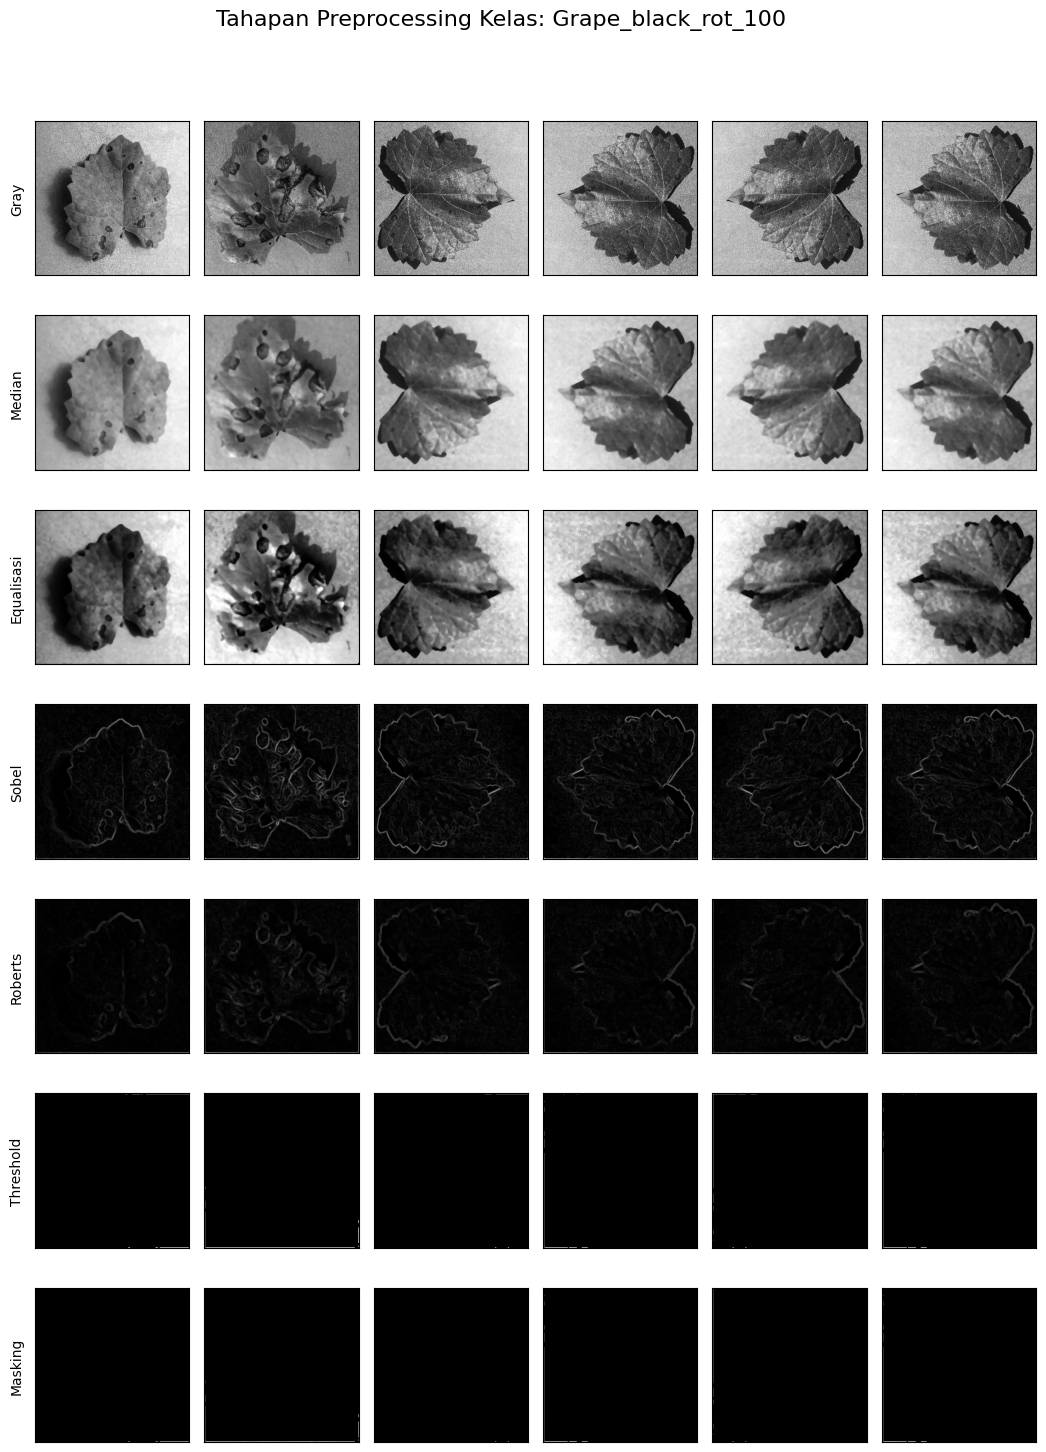

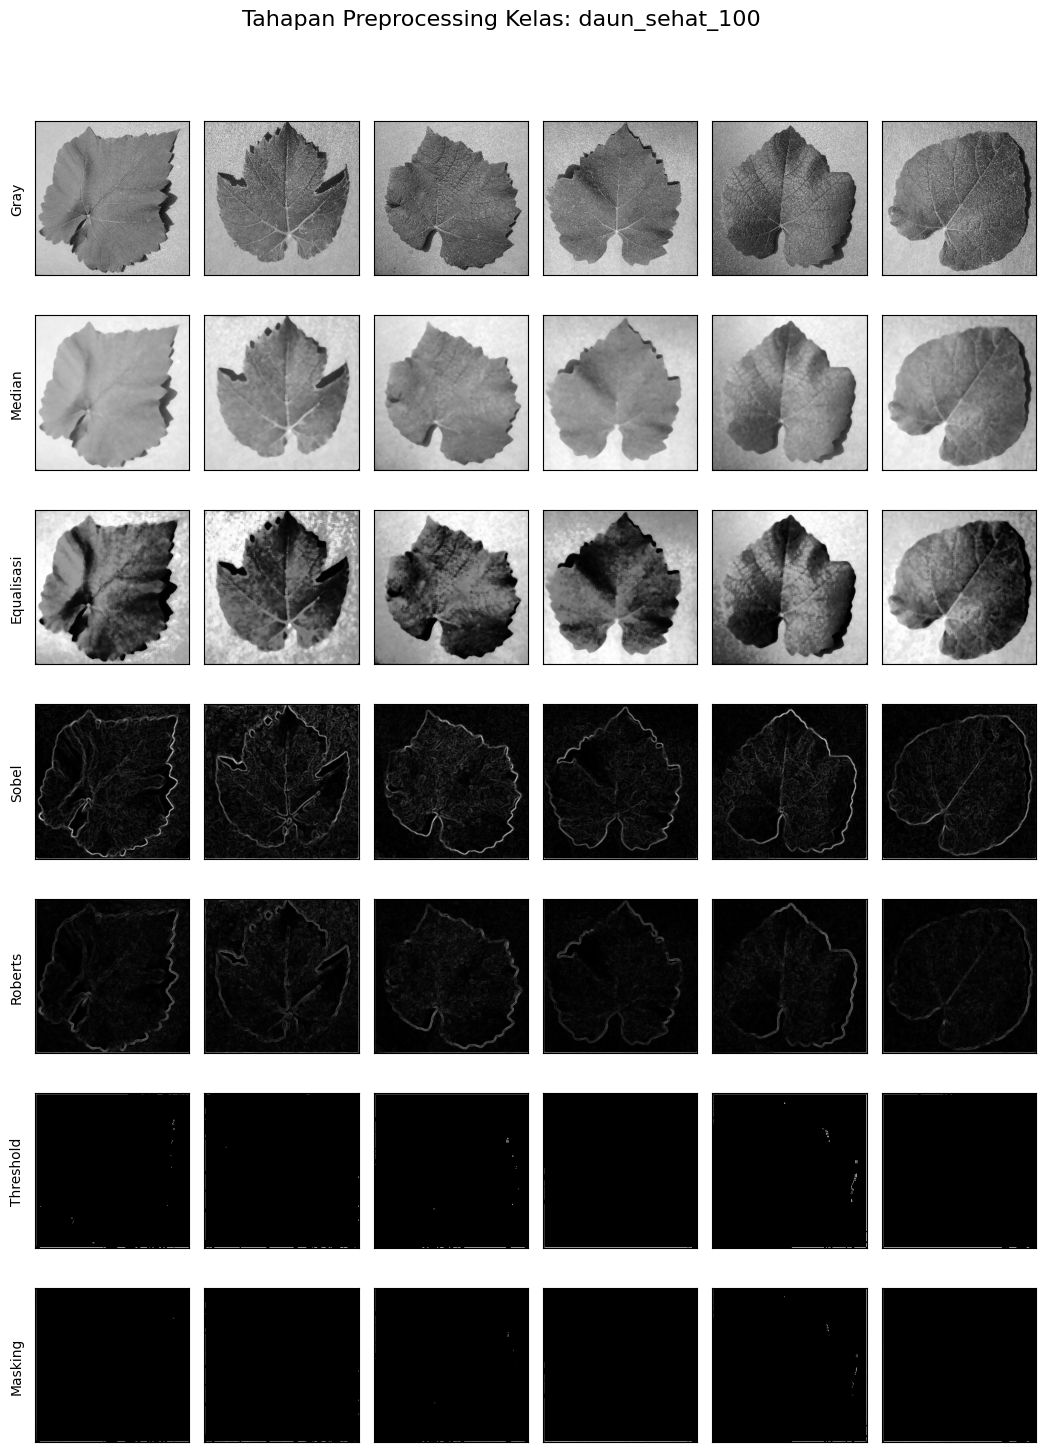

In [4]:
dataPreprocessed = [run_prepro(img) for img in data]
unique_labels = sorted(set(labels))
nama_step = ['Gray', 'Median', 'Equalisasi', 'Sobel', 'Roberts', 'Threshold', 'Masking']

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    n_sample = min(6, len(idxs))

    fig, axs = plt.subplots(7, 6, figsize=(11, 15))
    fig.suptitle(f'Tahapan Preprocessing Kelas: {label}', fontsize=16)

    for k in range(n_sample):
        img_asli = data[idxs[k]]
        hasil_tahap = prepro(img_asli)
        
        for row in range(7):
            axs[row][k].imshow(hasil_tahap[row], cmap='gray')
            axs[row][k].set_xticks([])
            axs[row][k].set_yticks([])
            if k == 0:
                axs[row][k].set_ylabel(nama_step[row], fontsize=10, labelpad=8)

    for k in range(n_sample, 6):
        for row in range(7):
            axs[row][k].axis('off')

    plt.tight_layout(rect=[0.04, 0, 1, 1])
    plt.subplots_adjust(top=0.92)
    plt.show()

## 5. Definisi Fungsi Feature Extraction GLCM

In [5]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Angle harus 0, 45, 90, atau 135.")
    
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Setelah gambar diisolasi melalui *Masking*, kita kembali memanggil metode *Gray-Level Co-occurrence Matrix* (GLCM) untuk mengekstrak tekstur matematisnya. Fungsi `glcm` bertugas menyusun matriks probabilitas kejadian piksel-piksel yang kini sudah berbentuk serpihan kerangka tersebut.

Sama seperti sebelumnya, kita menggunakan tujuh fungsi penarikan nilai fitur: `Correlation` (meninjau keteraturan pola struktur garis serpihan), `Contrast` dan `Dissimilarity` (menghitung perbedaan intensitas bercak kerangka), `Homogeneity` (menangkap kemulusan distribusi piksel tepi), `ASM` dan `Energy` (menakar konsistensi spasial yang tersisa), dan terakhir `Entropy` (mengukur tingkat keacakan garis siluet akibat jaringan yang terinfeksi jamur *Black Rot*).

## 6. Komputasi Matriks Probabilitas Multi-Sudut

In [6]:
Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []

for img in dataPreprocessed:
    Derajat0.append(glcm(img, 0))
    Derajat45.append(glcm(img, 45))
    Derajat90.append(glcm(img, 90))
    Derajat135.append(glcm(img, 135))

Guratan kerangka daun yang tertinggal setelah proses *Masking* bisa membentang ke banyak arah. Untuk merangkum semua informasi geometris yang bertebaran itu, matriks probabilitas dihitung secara serempak menyusuri empat sudut orientasi (0, 45, 90, dan 135 derajat). Matriks diagonal ini disimpan terpisah di dalam alokasi khusus.

## 7. Inisialisasi Array Feature Extraction

In [7]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Sebelum memulai proses penarikan nilai fitur, kita mendeklarasikan kembali 28 tempat penampungan (berupa *list array* kosong) agar hasil kalkulasi dari perpotongan ketujuh fitur dan keempat dimensi sudut tadi tidak berserakan.

## 8. Feature Extraction: Correlation

In [8]:
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

Langkah awal dari *Feature Extraction* ini ditujukan untuk membedah data `Correlation` (Korelasi). Algoritma akan menerjemahkan seberapa utuh struktur siluet tulang daun sehat berbanding dengan serpihan patah jaringan daun terinfeksi.

## 9. Feature Extraction: Contrast

In [9]:
for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

Pencatatan skor `Contrast` (Kekontrasan) direpetisi untuk mengevaluasi skala fluktuasi transisi piksel antar kerangka daun yang dipertahankan melawan *background* hitam mutlak yang mengelilinginya.

## 10. Feature Extraction: Dissimilarity

In [10]:
for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

Perhitungan parameter yang berdekatan dengan fitur sebelumnya ini melacak penyimpangan kekasaran linier melalui evaluasi indikator `Dissimilarity` (Ketidaksamaan). Fitur ini memperhalus tangkapan rentang perubahan skala mikro yang lolos dari lompatan rasio kontras.

## 11. Feature Extraction: Homogeneity

In [11]:
for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

Matriks observasi diteruskan pada pembacaan indeks `Homogeneity` (Homogenitas). Bagian ruang gelap mendominasi *Masking*, namun area batas jaringan daun akan tetap dinilai kelancaran dan penyebaran kepadatan teksturnya.

## 12. Feature Extraction: Entropy

In [12]:
for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

Penangkapan nilai keacakan dioperasikan melalui *looping* `Entropy` (Entropi). Efek metode *Masking* akan membuat struktur yang rusak karena jamur tampil pecah-pecah berhamburan layaknya rintik statis. Pola bintik yang kacau balau tersebut niscaya mencetak indikator entropi tertinggi.

## 13. Feature Extraction: ASM

In [13]:
for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

Ekstraksi dilanjutkan melalui pengukuran turunan stabilitas proporsi gambar lewat elemen `Angular Second Moment` (ASM), sehingga model mampu menakar tingkat keteraturan sebaran piksel pada kerangka gambar secara makro.

## 14. Feature Extraction: Energy

In [14]:
for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

Barisan rutinitas kalkulasi dieksekusi pungkas pada pengekstrak fungsional akar nilai ASM, yaitu `Energy` (Energi). Indeks ini menyederhanakan sebaran bilangan agar tidak memberatkan pengolahan memori mesin di siklus prediksi mendatang.

## 15. Pembentukan DataFrame

Keseluruhan 28 elemen nilai tekstur yang didapat sangat membutuhkan penyusunan struktur manajemen agar bisa dipahami sistem secara mudah dan efisien.

Kita menyulap kumpulan *array* yang berpencar tadi menjadi format `pandas DataFrame`. Masing-masing sampel citra kini diikat dengan informasi `Filename` dan `Label` asli kelas patologinya. Setelah baris di bawah dijalankan, penampakan *tabel data* rapi yang sudah sarat akan metrik tekstur siap disajikan secara tabular di hadapan .

In [15]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
display(df.head())

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,331.248591,549.548527,256.605653,549.630927,0.985556,0.980654,0.986304,0.980588,...,0.957662,0.957859,0.978479,0.978688,0.978602,0.978703,0.764235,0.541040,0.826765,0.540971
1,daun_sehat_100_2.jpg,daun_sehat_100,172.515579,278.909312,140.015824,280.948835,0.990737,0.988963,0.991396,0.988869,...,0.977155,0.977431,0.988251,0.988651,0.988512,0.988651,0.723137,0.447981,0.776752,0.443945
2,daun_sehat_100_3.jpg,daun_sehat_100,218.056572,458.420992,262.374510,460.254010,0.986746,0.982637,0.986689,0.982497,...,0.964658,0.964491,0.982001,0.982100,0.982170,0.982085,0.807262,0.497630,0.761224,0.495621
3,daun_sehat_100_4.jpg,daun_sehat_100,149.346553,339.096440,216.529029,344.166920,0.993095,0.991128,0.993286,0.991123,...,0.981582,0.982028,0.990978,0.991019,0.990748,0.990973,0.785376,0.328695,0.659250,0.318657
4,daun_sehat_100_5.jpg,daun_sehat_100,243.066131,488.021745,287.896676,492.096486,0.987212,0.982955,0.986346,0.982922,...,0.966162,0.965215,0.982430,0.982500,0.982935,0.982454,0.783069,0.455910,0.733031,0.451368


## 16. Feature Selection dengan Threshold Korelasi

Ada begitu banyak dimensi fitur numerik yang kita kumpulkan. Jika ternyata sebagian darinya hanya membocorkan informasi redundan atau sebatas duplikasi belaka, sistem hanya akan kebingungan (*overfitting*) dan malah menurukan kualitas ramalannya.

Proses filterisasi kemiripan ini dilakukan menggunakan korelasi dengan ambang batas (threshold) 0.95. Begitu dua relasi fitur menunjukan koneksi melampaui rentang tersebut, salah satunya akan digugurkan. Penurunan jumlah dimensi ini akan terekam dan tercetak lewat output sistem, sembari disertai suguhan tampilan diagaram kotak biru *Heatmap Correlation* yang mengkonfirmasi kemerdekaan antar tiap fitur yang selamat.

Fitur awal (sebelum seleksi)  : 28
Fitur akhir (setelah seleksi) : 7
Fitur fungsional terpilih     : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Correlation0', 'Correlation45', 'Correlation90']


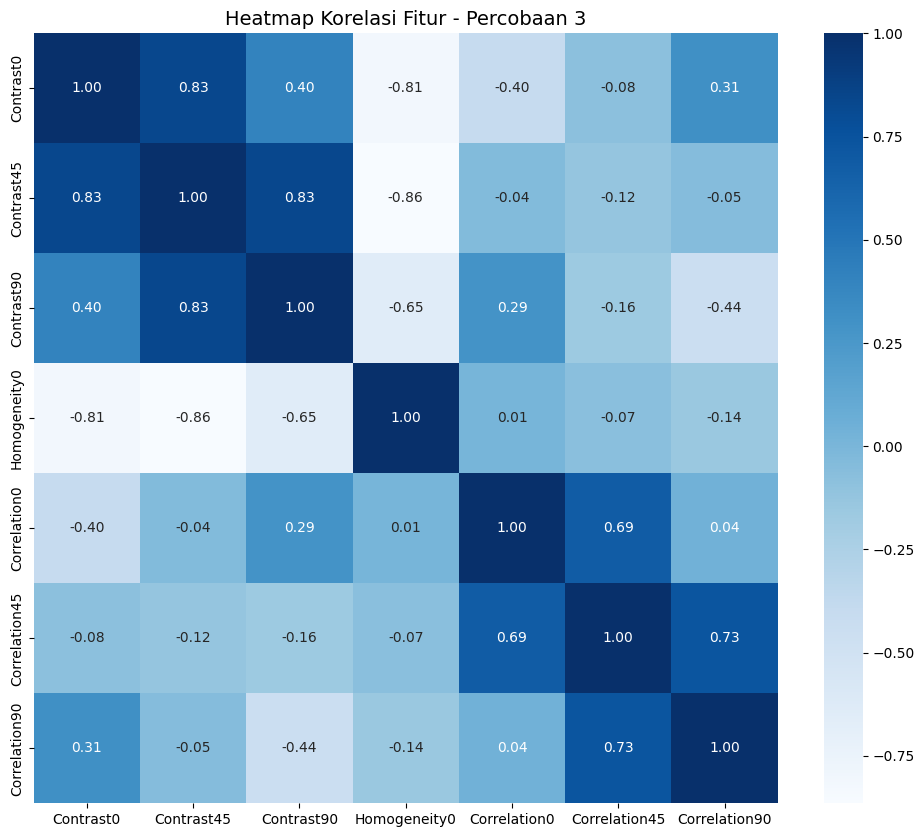

In [16]:
corr_matrix = df.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns_to_keep = np.full((corr_matrix.shape[0],), True, dtype=bool)

for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns_to_keep[j]:
                columns_to_keep[j] = False

selected_columns = df.drop(columns=['Label','Filename']).columns[columns_to_keep]
X_selected = df[selected_columns]
y = df['Label']

print(f"Fitur awal (sebelum seleksi)  : 28")
print(f"Fitur akhir (setelah seleksi) : {len(selected_columns)}")
print(f"Fitur fungsional terpilih     : {list(selected_columns)}")

plt.figure(figsize=(12, 10))
sns.heatmap(X_selected.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

## 17. Data Splitting (Train & Test)

Saat melatih *Machine Learning*, kecurangan komputasi sangat gampang terjadi bila algoritma diuji dari kelompok data bocoran yang sama dengan materi ujian pelatihannya.

Demi obyektivitas absolut, set dataset akan dibedah melalu fungsi `train_test_split` ke dalam persentase 80:20 secara *random*. Komposisi mayoritas (80%) diperuntukkan murni untuk pelatihan model (*Train Data*), meninggalkan sisanya (20%) sebagai kurungan tes (*Test Data*). Output luaran dari blok ini akan memvalidasi dimensi porsi matriks pasca-pemotongan.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print("Ukuran Set Data Latih (X_train, y_train): ", X_train.shape, y_train.shape)
print("Ukuran Set Data Uji (X_test, y_test)    : ", X_test.shape, y_test.shape)

Ukuran Set Data Latih (X_train, y_train):  (160, 7) (160,)
Ukuran Set Data Uji (X_test, y_test)    :  (40, 7) (40,)


## 18. Feature Normalization (Z-Score)

Karena fitur pengujian seperti *SVM* dan metrik titik letak layaknya *KNN* memproses jarak matematis absolut, skala angka yang campur aduk sangat mengancam dominansi komputasi parameter model.

Masalah bias dipecahkan melalui skenario perataan jangkauan angka *Z-Score Normalization*. Penyetaraan eksponensial ini meringkus sebaran grafik secara lurus simetris di titik mean absolut 0 (nol) serta limit standar baku (satu). Data yang dinormalisasi sepenuhnya terisolir pada perhitungan rata-rata `X_train` demi memblokade tumpahan relasi acuan matriks pada tahapan ujian akhir nanti. Hasil perataan tersebut akan tercetak menjadi *DataFrame* ringkas di bawah.

In [18]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

print("Verifikasi hasil distribusi Z-Score Normalization (Train Data):")
display(X_train.head())

Verifikasi hasil distribusi Z-Score Normalization (Train Data):


,Contrast0,Contrast45,Contrast90,Homogeneity0,Correlation0,Correlation45,Correlation90
79,0.791359,0.997468,0.793935,-0.310524,-0.746897,-1.259683,-0.683060
197,1.677952,1.844307,1.438645,-1.086818,-0.380283,-0.543683,-0.199943
38,2.142434,2.645106,2.076674,-2.472693,0.504849,0.554142,0.465040
24,0.234520,-0.458718,-1.003152,0.135614,-0.053869,0.839799,1.162800
122,0.149757,-0.850131,-1.677542,0.318479,0.001059,1.261593,1.760434


## 19. Inisialisasi Model Klasifikasi

In [19]:
def generateClassificationReport(y_true, y_pred, model_name):
    print(f"=== Laporan Metrik Evaluasi: {model_name} ===")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    print(f"Accuracy Score: {accuracy_score(y_true, y_pred) * 100:.2f}%\n")

rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Sebelum memulai uji persaingan terakhir, satu fungsi pelaporan *dashboard* disiapkan yakni `generateClassificationReport`. Blok fungsi sentral ini mengelola *output* supaya nilai rentetan akurasi klasifikasi (*Classification Report*) serta visual kotak tebakan biru dari *Confusion Matrix* langsung tersaji runut di depan layar secara paralel.

Secara berturut-turut kita pun mengaktifkan 3 pendekar pengenalan pola:
1. **Random Forest (rf)**: Penggabungan kecerdasan cabang-cabang putusan komputasi.
2. **Support Vector Machine (svm)**: Garis belah ruang kernel RBF, pencari jalan pisah dimensi koordinat melengkung.
3. **K-Nearest Neighbors (knn)**: Ekstraksi putusan berbasis identitas observasi yang melacak jarak irisan pada kelompok 5 sampel observasi paling berhimpitan.

## 20. Evaluasi Model Random Forest

Panggung percobaan perdana dieksekusi dengan mendidik algoritma majemuk *Random Forest*. Fase orientasi data terpacu pada metode `.fit()` untuk menyusun rasio komparasi *Data Latih* (*Black Rot* melawan Daun Sehat). Sesudah fase tersebut selesai, arsitektur yang terlatih ini dilepas langsung pada area pengasingan *Data Uji* untuk memprediksi identitas gambar di luar hafalan basis datanya.

Berdasarkan performa uji di tahapan `pre 3` ini, Random Forest mencetak angka ketepatan sekitar **82.5%**. Angka ini jauh di bawah titik sempurna yang ia raih ketika hanya dihadapkan pada gambar utuh (*pre 1* 97.5%) atau gambar deteksi tepi biasa (*pre 2* 92.5%). Kegagalan ini menjawab eksperimen hipotesis kita: isolasi memotong siluet *Masking* ternyata membuat model kebingungan mencari pijakan tekstur karena terlampau banyak komponen rona daun yang lenyap diganti hitam!

=== Laporan Metrik Evaluasi: Random Forest ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.77      0.89      0.83        19
     daun_sehat_100       0.89      0.76      0.82        21

           accuracy                           0.82        40
          macro avg       0.83      0.83      0.82        40
       weighted avg       0.83      0.82      0.82        40



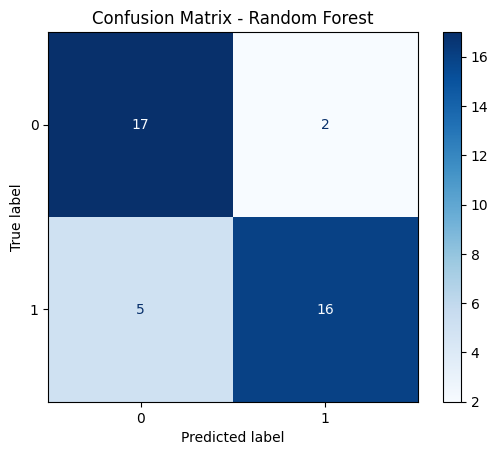

Accuracy Score: 82.50%



In [20]:
rf.fit(X_train, y_train)

prediksi_rf = rf.predict(X_test)
generateClassificationReport(y_test, prediksi_rf, "Random Forest")

## 21. Evaluasi Model Support Vector Machine

Gelanggang uji selanjutnya menyajikan kekuatan arsitektur pisah linear kelompok kelas spesifik, sang model pamungkas Support Vector Machine (SVM). Kapasitas manipulasi kelengkungan melalui trik kernel *RBF* difungsikan mendongkrak performa kalkulasi koordinat dimensi ruang ekstraksi citra tersisa.

Mengonfirmasi malapetaka prediksi model pertama, rapor model andalan sekelas SVM anjlok bebas ke jurang persentase **77.5%**. Padahal di *pre 1* model inilah yang meraih poin mutlak 100%! Fakta memilukan di `pre 3` ini menggarisbawahi bahwa ketangkasan algoritma *Support Vector Machine* tidak bisa diselamatkan apalagi digenjot dengan data tekstur yang sengaja dirusak belahannya lewat teknik `Masking`. Area blok hitam luas tanpa tekstur yang tersisa setelah gambar dipotong justru menjadi sumber *noise* linearitas yang merusak pembelahan *hyperplane* rbf miliknya.

=== Laporan Metrik Evaluasi: Support Vector Machine ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.75      0.79      0.77        19
     daun_sehat_100       0.80      0.76      0.78        21

           accuracy                           0.78        40
          macro avg       0.78      0.78      0.77        40
       weighted avg       0.78      0.78      0.78        40



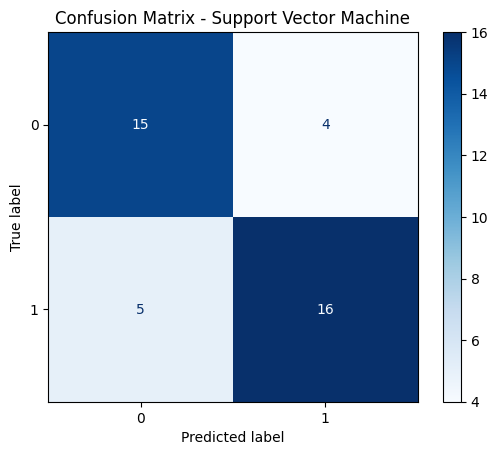

Accuracy Score: 77.50%



In [21]:
svm.fit(X_train, y_train)

prediksi_svm = svm.predict(X_test)
generateClassificationReport(y_test, prediksi_svm, "Support Vector Machine")

## 22. Evaluasi Model K-Nearest Neighbors

Evaluasi ketiga, yang bertindak memungkasi perbandingan validasi ditutup melalui kinerja metrik referensi lingkungan klasikal, yaitu algoritma *K-Nearest Neighbors* (KNN).

Nasib naas tidak terhindarkan dari KNN yang harus menanggung kerumitan dari pembuangan informasi latar secara paksa. Ia pun mentok meraih ketajaman observasi tak lebih dari level **80.0%**. Rentang ini membuktikan betapa perlakuan *Masking Threshold* mengubah tatanan letak korelasi serpihan spasial sedemikian ekstremnya, hingga titik hitung jarak antar ketetanggaan (*Neighbors distance*) daun yang sehat maupun berpenyakit melebur, saling mengelabui, dan bertabrakan satu sama lain.

=== Laporan Metrik Evaluasi: K-Nearest Neighbors ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.72      0.95      0.82        19
     daun_sehat_100       0.93      0.67      0.78        21

           accuracy                           0.80        40
          macro avg       0.83      0.81      0.80        40
       weighted avg       0.83      0.80      0.80        40



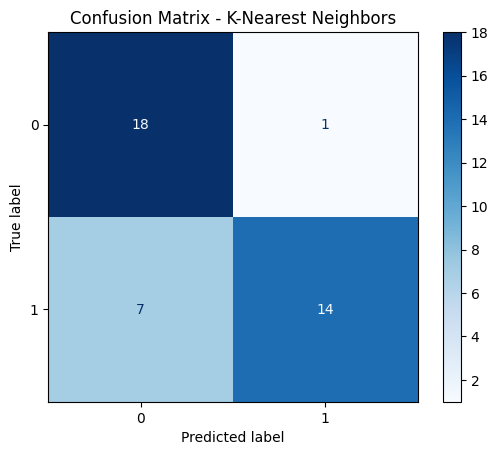

Accuracy Score: 80.00%



In [22]:
knn.fit(X_train, y_train)

prediksi_knn = knn.predict(X_test)
generateClassificationReport(y_test, prediksi_knn, "K-Nearest Neighbors")

## 23. Kesimpulan Akhir: Evaluasi Tiga Pendekatan Preprocessing

Melalui penyusunan tiga tahap modifikasi dataset daun *Grape Black Rot* (`pre 1`, `pre 2`, dan `pre 3`), kita berhasil membongkar realita luar biasa mengenai sifat rapuh algoritma pendeteksi pola *Machine Learning* terhadap modifikasi gambar:

1. **Pipeline 1 (Minimalis & Natural):** Pada tahapan paling mendasar ini, kita murni mengandalkan penghalusan spasial (*Median*) dan pendongkrak kontras warna (*Histogram Equalization*), tanpa menyentuh esensi keutuhan daun. Ajaibnya, pendekatan ini sukses mendulang *Accuracy Score* spektakuler hingga **100%** (SVM & KNN) serta **97.5%** (Random Forest). Keutuhan rona gradasi alami pada bintik pekat *Black Rot* dan mulusnya warna daun bersih ternyata paling disukai model secara algoritmik.
2. **Pipeline 2 (Penegasan Kerangka / Edge Detection):** Ambisi untuk membantu model mengenali penyakit daun melalui penambahan operator pendeteksi tepi (*Sobel & Roberts*) ternyata menelan pil pahit penurunan. Keakuratan secara massal tergusur ke angka mentok **92.5%** pada tiga model sekaligus. Garis siluet tajam ini menyembunyikan karakteristik fundamental rona bercak daun, menyingkirkan elemen homogenitas tekstur asli dan menyisakan jaring kusut berupa pola yang agak ambigu (*false positives*) saat dibaca.
3. **Pipeline 3 (Eksperimen Isolasi / Masking Threshold):** Menyisipkan operasi drastis `Masking` untuk memusnahkan area *background* di sekeliling siluet tepi menjadi *blunder* paling brutal dalam ekstraksi tekstur. Akurasi hancur berkeping-keping menjadi **77.5% - 82.5%** secara beruntun. Keputusan merubah citra menjadi sekumpulan kerangka melayang di atas laut hitam *background* yang merata, nyatanya menghancurkan sebaran *Probability Matrix (GLCM)* yang menjadi pilar tumpuan perhitungan nilai entropi, homogenitas, dan kontras. 

**Intisari yang bisa kita petik:** 
Dataset  ini sudah sangat bagus dan memiliki fitur bawaan (*natural features*) yang sangat kuat. Karena datasetnya sudah bagus, pola bercak hitam (*Black Rot*) pada daun berpenyakit dan tekstur mulus pada daun sehat itu sudah **sangat kontras dan mudah dibedakan** secara alami. 

Itulah mengapa di `pre 1`, saat kita hanya meratakan warnanya sedikit tanpa merusak bentuk asli daun, mesin bisa langsung menebak dengan akurasi **100%**. Mesin dengan mudah mempelajari: *"Oh, kalau ada tekstur bercak bulat-bulat gelap seperti ini, berarti Black Rot"*.

Sebaliknya, ketika kita mencoba sok pintar dengan menambahkan deteksi tepi (`pre 2`) atau memotong paksa *background* (`pre 3`), kita malah **menghancurkan** pola alami tersebut. Bercak jamur yang tadinya terlihat jelas malah berubah menjadi sekumpulan garis putus-putus tak beraturan, yang akhirnya malah membuat mesin kebingungan (turun ke 77%).

Jadi, analisis ini justru menjadi sebuah temuan akademik yang sangat keren untuk laporan atau presentasi  kelak: **"Dataset citra Grape Black Rot ini memiliki diferensiasi tekstur spasial yang sangat baik secara bawaan, sehingga pendekatan *preprocessing* minimalis terbukti jauh lebih superior dan efisien dibandingkan manipulasi bentuk yang ekstrim."**